### Code and data to reproduce plots from "The Surface Orientation Ambiguity for Single Molecules at Dielectric Interfaces"

In [1]:
import sys
import os
import numpy as np
import pickle as pkl
import matplotlib.pyplot as plt

In [2]:
def fresnel_coefficients(n_in, n_out, rho):
    sin_theta_in = rho
    cos_theta_in = np.sqrt(1.0 - sin_theta_in**2,dtype=complex)

    sin_theta_out = (n_in / n_out) * sin_theta_in
    cos_theta_out= np.sqrt(1.0 - sin_theta_out**2,dtype=complex)
    
    t_s = 2.0 * n_in * cos_theta_in / (n_in * cos_theta_in + n_out * cos_theta_out)
    t_p = 2.0 * n_in * cos_theta_in / (n_in * cos_theta_out + n_out * cos_theta_in)
    r_s= (n_in * cos_theta_in-n_out * cos_theta_out)/(n_in * cos_theta_in+n_out * cos_theta_out)
    r_p= (n_out * cos_theta_in-n_in * cos_theta_out)/(n_out * cos_theta_in+n_in * cos_theta_out)
    return t_s, t_p, r_s, r_p

def C_opositeside(n_dip, n_other, k, Δ,theta):
    #thetaout=-np.abs(thetao)
    sz=np.sqrt((n_dip/n_other)**2-np.sin(theta)**2,dtype=complex)
    thetain=np.arcsin(n_other/n_dip*np.sin(theta),dtype=complex)
    ts,tp,_,_=fresnel_coefficients(n_dip+1e-6j,n_other+1e-6j,np.sin(thetain))
    phase =1j * k * Δ *n_other* sz
    c1 = (n_other/n_dip)*tp*(np.cos(theta)/sz)*np.exp(phase)
    c2 = -(n_other/n_dip)*tp*np.exp(phase)
    c3 = ts*(np.cos(theta)/sz)*np.exp(phase)
    return c1,c2,c3
    
def C_dipoleside(n_dip, n_other, k, Δ,theta):
    theta=np.abs(theta)
    _,_,rs,rp=fresnel_coefficients(n_dip,n_other,np.sin(theta))
    phase = -1j * k * n_dip*Δ*np.cos(theta)
    c1 = np.exp(phase)+rp*np.exp(-phase)
    c2 = -(np.exp(phase)-rp*np.exp(-phase))
    c3 = np.exp(phase)+rs*np.exp(-phase)
    return c1, c2, c3


def Power_opositeside(n_dip, n_other, k, Δ, p_vec, phi, theta):
    
    c1,c2,c3=C_opositeside(n_dip, n_other, k, Δ,theta)
    [px,py,pz]=p_vec
    # In this scenario, n_other/n_dip appears as in Novotny 10.43.
    f=3/(8*np.pi) * n_other/n_dip  
    t1=pz**2*np.sin(theta)**2*np.abs(c1)**2
    t2=(px*np.cos(phi)+py*np.sin(phi))**2*np.cos(theta)**2*np.abs(c2)**2
    t3=(px*np.sin(phi)-py*np.cos(phi))**2*np.abs(c3)**2
    t4=-pz*(px*np.cos(phi)+py*np.sin(phi))*np.cos(theta)*np.sin(theta)*(np.conjugate(c1)*c2+c1*np.conjugate(c2))
    return f*(t1+t2+t3+t4)

def Power_dipoleside(n_dip,n_other, k, Δ, p_vec, phi, theta):

    c1,c2,c3=C_dipoleside(n_dip, n_other, k, Δ,theta)
    [px,py,pz]=p_vec
    
    #Novotny gives p/P0 where P0 is power from a dipole in medium 1
    # But here we in fact have medium 1 = glass, and we are taking ratios to power of an air dipole.
    # An air dipole radiates n_air/n_glass as much as a glass dipole (Novotny 8.71)
    # So we need to multiply by a factor n_glass/n_air, which is n_dip/n_other
    f=3/(8*np.pi)*n_dip/n_other
    
    t1=pz**2*np.sin(theta)**2*np.abs(c1)**2
    t2=(px*np.cos(phi)+py*np.sin(phi))**2*np.cos(theta)**2*np.abs(c2)**2
    t3=(px*np.sin(phi)-py*np.cos(phi))**2*np.abs(c3)**2
    t4=-pz*(px*np.cos(phi)+py*np.sin(phi))*np.cos(theta)*np.sin(theta)*(np.conjugate(c1)*c2+c1*np.conjugate(c2))
    return f*(t1+t2+t3+t4)



## Dipolar patterns

In [3]:
import pandas as pd

cols=['theta']
for i in np.arange(0,1001,25):
    cols.append('farfield'+str(i))
    cols.append('dummy'+str(i))
dat_above=pd.read_csv("Data/RadPatternPlus_higherres.txt",skiprows=8,sep='\\s+',names=cols)
dat_below=pd.read_csv("Data/RadPatternMinus_higherres.txt",skiprows=8,sep='\\s+',names=cols)
dat_above250=pd.read_csv("Data/RadPatternPlus_250_higherres.txt",skiprows=8,sep='\\s+',names=cols)
dat_below250=pd.read_csv("Data/RadPatternMinus_250_higherres.txt",skiprows=8,sep='\\s+',names=cols)
dat_above50=pd.read_csv("Data/RadPatternPlus_50_higherres.txt",skiprows=8,sep='\\s+',names=cols)
dat_below50=pd.read_csv("Data/RadPatternMinus_50_higherres.txt",skiprows=8,sep='\\s+',names=cols)
dat_above25=pd.read_csv("Data/RadPatternPlus_25_higherres.txt",skiprows=8,sep='\\s+',names=cols)
dat_below25=pd.read_csv("Data/RadPatternMinus_25_higherres.txt",skiprows=8,sep='\\s+',names=cols)


cols=['theta']
for i in np.arange(0,1001,100):
    cols.append('farfield'+str(i))
    cols.append('dummy'+str(i))
dat_allair=pd.read_csv("Data/RadPatternMinus_AllAir_100.txt",skiprows=8,sep='\\s+',names=cols)


cols=['theta']
for i in np.arange(1000,3000,100):
    cols.append('farfield'+str(i))
    cols.append('dummy'+str(i))
dat_above_long=pd.read_csv("Data/RadPatternPlus_100_long.txt",skiprows=8,sep='\\s+',names=cols)
dat_below_long=pd.read_csv("Data/RadPatternMinus_100_long.txt",skiprows=8,sep='\\s+',names=cols)

In [4]:
theta_dip=0
phi_dip=0
p_vec=[np.sin(theta_dip)*np.sin(phi_dip),np.sin(theta_dip)*np.cos(phi_dip),np.cos(theta_dip)]
phi=np.pi/2
nair=1
nglass=1.5
lam=550e-9
k=2*np.pi/lam
delta=1e-9
print(p_vec)
thetas=np.linspace(-np.pi/2,np.pi/2,1000)


[0.0, 0.0, 1.0]


/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_12697/1234107547.py:8: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1,1,figsize=(10,4),subplot_kw={'projection': 'polar'})


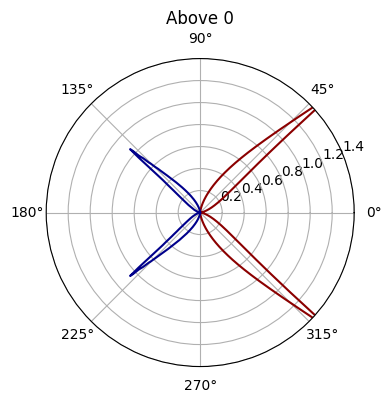

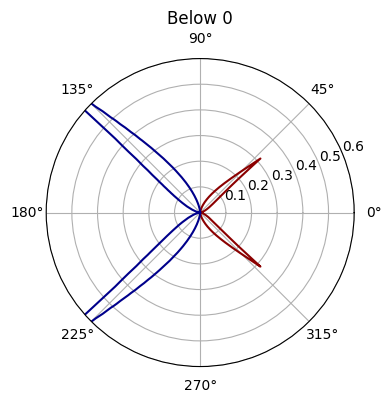

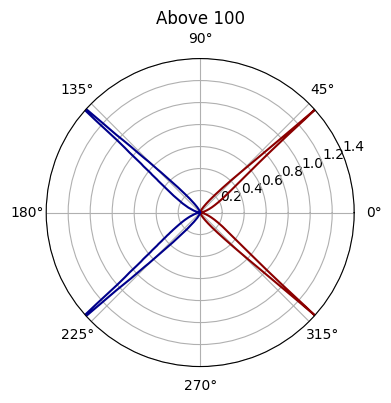

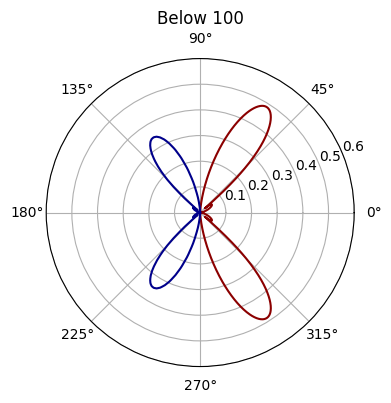

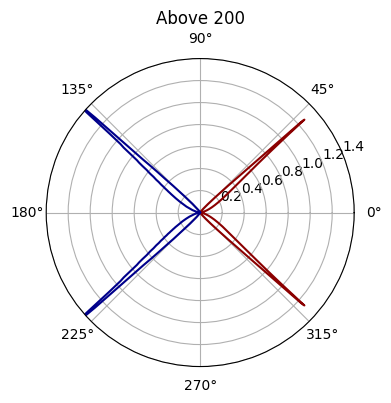

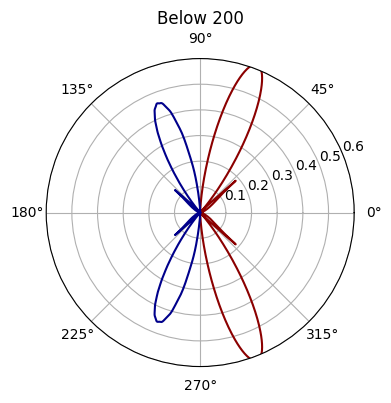

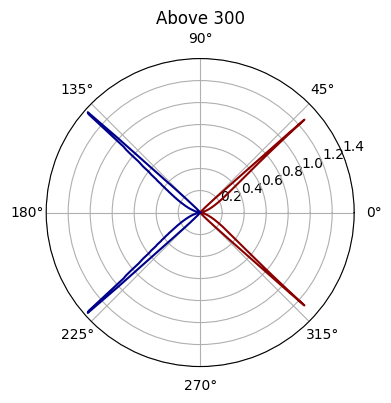

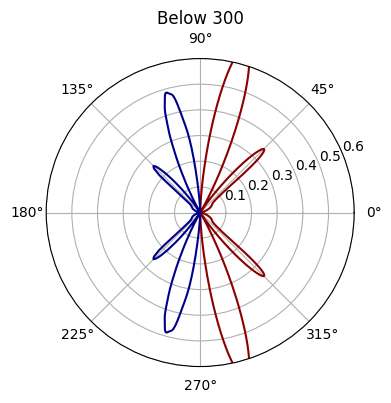

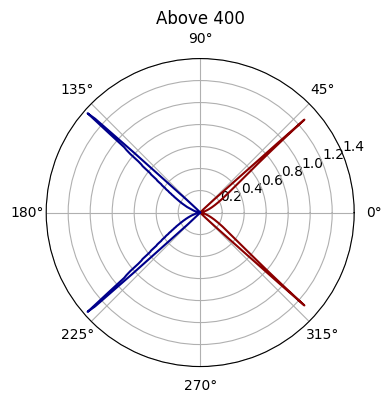

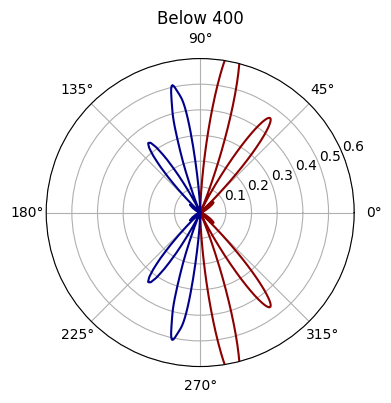

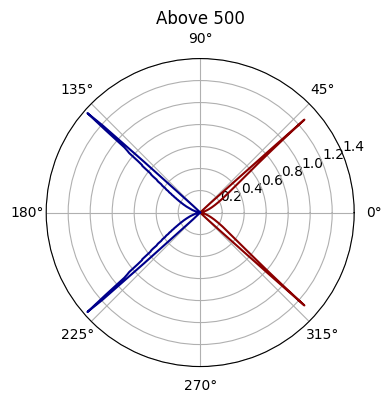

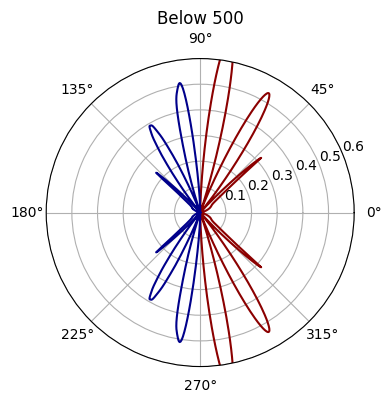

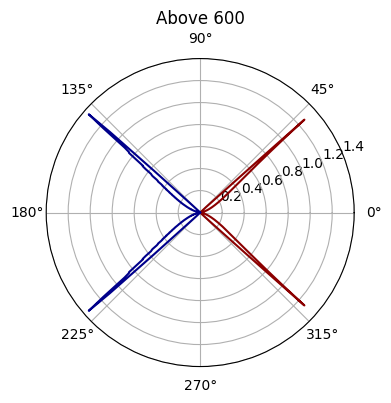

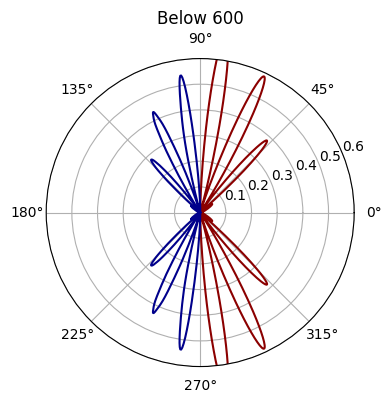

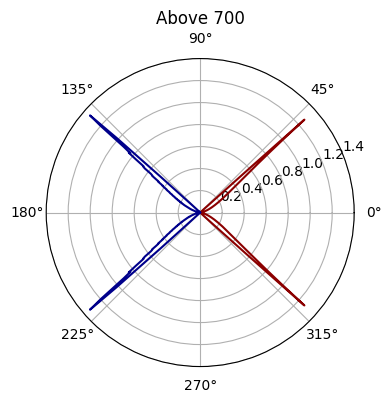

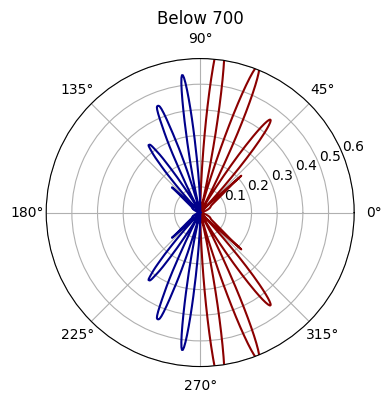

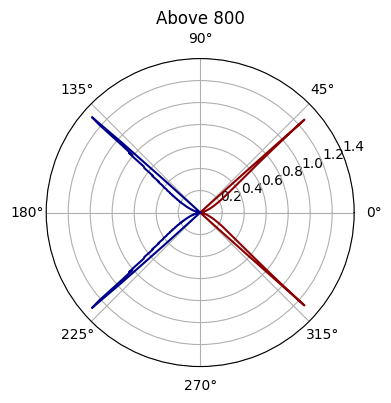

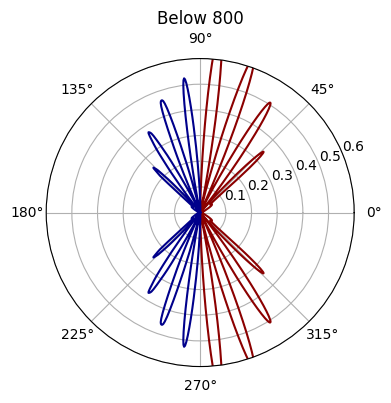

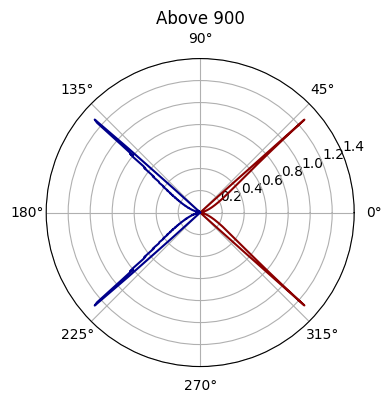

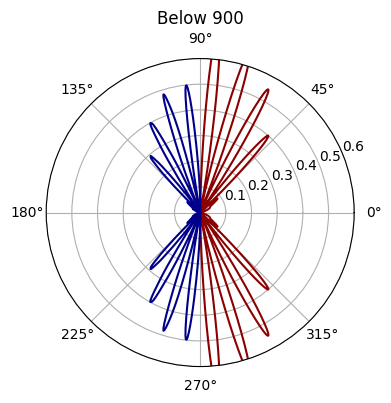

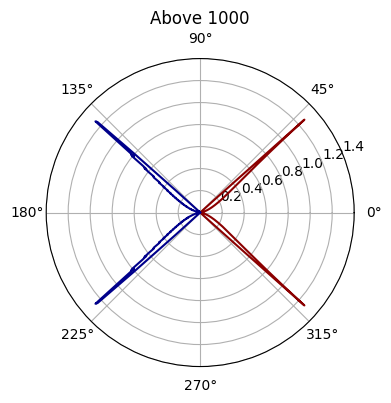

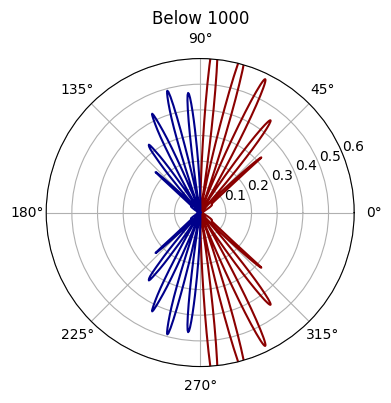

In [5]:
for i in np.arange(0,1100,100):
    delta=i*1e-9    
    pow_dipabove_down=Power_opositeside(nair,nglass , k ,delta,p_vec,phi,thetas)
    pow_dipbelow_down=Power_dipoleside(nglass,nair , k ,delta,p_vec,phi,thetas)

    #note, |S| = |E x H| = |E|^2 n. So need to square Efar and multiply by n  
    
    fig, ax = plt.subplots(1,1,figsize=(10,4),subplot_kw={'projection': 'polar'})
    ax.plot(thetas,np.abs(pow_dipabove_down),color='DarkRed')
    ax.plot(dat_above.theta,dat_above['farfield'+str(i)]**2*1.1e14,color='DarkBlue') # these are arb numbers just to make similar size
    ax.set_title('Above ' + str(int(delta/1e-9)))
    ax.set_rlim(0,1.4)
    fig, ax = plt.subplots(1,1,figsize=(10,4),subplot_kw={'projection': 'polar'})
    ax.plot(thetas,np.abs(pow_dipbelow_down),color='DarkRed')
    ax.plot(dat_below.theta,dat_below['farfield'+str(i)]**2*1.1e14,color='DarkBlue') # these are arb numbers just to make similar size
    ax.set_title('Below ' + str(int(delta/1e-9)))
    ax.set_rlim(0,0.6)
    

In [6]:
def GetPowerFromComsolFile(fname,values=np.arange(0,1001,25)):
    totpower={}
    cols=['theta']
    for i in values:
        cols.append('farfield'+str(i))
        cols.append('dummy'+str(i))
    dat=pd.read_csv(fname,skiprows=8,delim_whitespace=True,names=cols)
    for i in values:
        totpower[i]=4*np.pi*sum(np.abs(np.sin(dat.theta))*dat['farfield'+str(i)])/len(dat.theta)
    return totpower, dat

def GetPowerFromComsolFile2D(fname,values=np.arange(0,1001,25)):
    totpower={}
    cols=['theta']
    for i in values:
        cols.append('farfield'+str(i))
        cols.append('dummy'+str(i))
    dat=pd.read_csv(fname,skiprows=8,delim_whitespace=True,names=cols)
    for i in values:
        totpower[i]=2*np.pi*sum(dat['farfield'+str(i)])/len(dat.theta)
    return totpower, dat

In [7]:
totpower_comsol_down50, dat50=GetPowerFromComsolFile("Data/RadPatternMinus_50_higherres.txt")
totpower_comsol_up50,_=GetPowerFromComsolFile("Data/RadPatternPlus_50_higherres.txt")
totpower_comsol_down100,_=GetPowerFromComsolFile("Data/RadPatternMinus_higherres.txt")
totpower_comsol_up100,_=GetPowerFromComsolFile("Data/RadPatternPlus_higherres.txt")
totpower_comsol_down25,_=GetPowerFromComsolFile("Data/RadPatternMinus_25_higherres.txt")
totpower_comsol_up25,_=GetPowerFromComsolFile("Data/RadPatternPlus_25_higherres.txt")
totpower_comsol_down250,_=GetPowerFromComsolFile("Data/RadPatternMinus_250_higherres.txt")
totpower_comsol_up250,_=GetPowerFromComsolFile("Data/RadPatternPlus_250_higherres.txt")

totpower_theory_up=[]
totpower_theory_down=[]

theory_deltas=np.arange(0,3001,1)
for i in theory_deltas:
    delta=i*1e-9    
    
    pow_dipabove_down=Power_opositeside(nair,nglass , k ,delta,p_vec,phi,thetas)
    pow_dipbelow_down=Power_dipoleside( nglass,nair , k ,delta,p_vec,phi,thetas)
        
    totpower_theory_down.append(2.*np.pi*sum(np.abs(np.sin(thetas))*np.abs(pow_dipbelow_down))*(np.pi/(2*len(thetas))))
    totpower_theory_up.append(  2.*np.pi*sum(np.abs(np.sin(thetas))*np.abs(pow_dipabove_down))*(np.pi/(2*len(thetas))))

experiment_deltas=np.arange(0,1001,25)


/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_12697/1114346989.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dat=pd.read_csv(fname,skiprows=8,delim_whitespace=True,names=cols)
/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_12697/1114346989.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dat=pd.read_csv(fname,skiprows=8,delim_whitespace=True,names=cols)
/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_12697/1114346989.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dat=pd.read_csv(fname,skiprows=8,delim_whitespace=True,names=cols)
/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_12697/1114346989.py:7: FutureWarning: The 'delim_whitespace' k

In [8]:
vals=[]
for n in (1,1.5):
    for rr in (10,25,50,100,250):
        vals.append(str(n)+"_"+str(rr))
normcyl, dat=GetPowerFromComsolFile("Data/Export_Power_TwoRefIndices_cylinders_denominators.txt",vals)
normsphere, dat=GetPowerFromComsolFile("Data/Export_Power_TwoRefIndices_spheres_denominators.txt",vals)

/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_12697/1114346989.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dat=pd.read_csv(fname,skiprows=8,delim_whitespace=True,names=cols)
/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_12697/1114346989.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dat=pd.read_csv(fname,skiprows=8,delim_whitespace=True,names=cols)


<>:42: SyntaxWarning: invalid escape sequence '\D'
<>:43: SyntaxWarning: invalid escape sequence '\D'
<>:42: SyntaxWarning: invalid escape sequence '\D'
<>:43: SyntaxWarning: invalid escape sequence '\D'
/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_12697/195839100.py:42: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(theory_deltas, totpower_theory_up,color='blue',label='Theory $\Delta^+$',linewidth=2)
/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_12697/195839100.py:43: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(-theory_deltas, totpower_theory_down,color='DarkBlue',label='Theory $\Delta^-$',linewidth=2)
/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_12697/1114346989.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dat=pd.read_csv(fname,skiprows=8,delim_whitespace=True,names=cols)
/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/i

Text(0.5, 0, 'z (nm)')

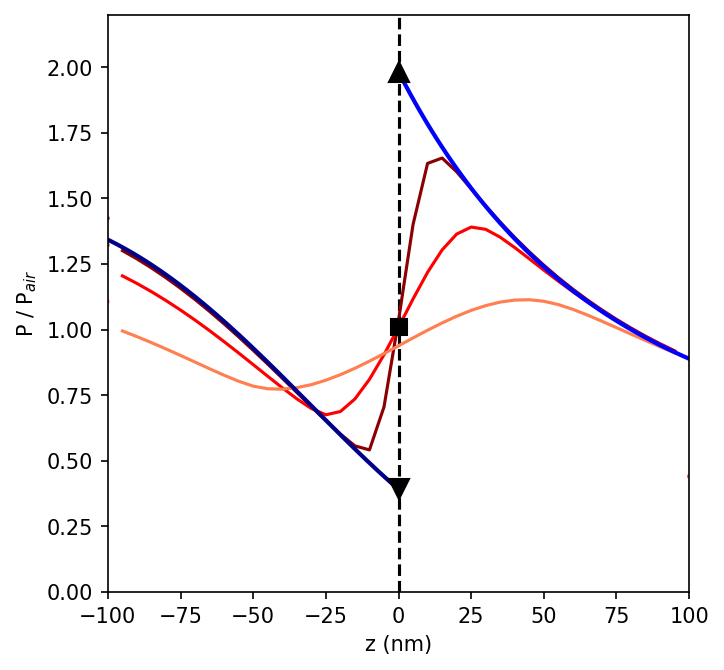

In [9]:
plt.figure(figsize=(5,5),dpi=150)
vals=np.arange(1,501,25)

plt.plot([0,0],[0,2.2],'--',color='black')


vals=np.arange(0,100,5)
above10, _ =GetPowerFromComsolFile("Data/Export_Power_Above_10_fine_sphere.txt",vals)
below10, _ =GetPowerFromComsolFile("Data/Export_Power_Below_10_fine_sphere.txt",vals)
plt.plot(vals,np.array(list(above10.values()))/normsphere["1_10"]*nglass,color='DarkRed',label='Numerical, 10 nm')
plt.plot(-vals,np.array(list(below10.values()))/normsphere["1_10"]*nglass,color='DarkRed')

above25, _ =GetPowerFromComsolFile("Data/Export_Power_Above_25_fine_sphere.txt",vals)
below25, _ =GetPowerFromComsolFile("Data/Export_Power_Below_25_fine_sphere.txt",vals)
plt.plot(vals,np.array(list(above25.values()))/normsphere["1_25"]*nglass,color='red',label='Numerical, 25 nm')
plt.plot(-vals,np.array(list(below25.values()))/normsphere["1_25"]*nglass,color='red')

dot25=below25[0]/normsphere["1_25"]*nglass

above50, _ =GetPowerFromComsolFile("Data/Export_Power_Above_50_fine_sphere.txt",vals)
below50, _ =GetPowerFromComsolFile("Data/Export_Power_Below_50_fine_sphere.txt",vals)
plt.plot(vals,np.array(list(above50.values()))/normsphere["1_50"]*nglass,color='coral',label='Numerical, 50 nm')
plt.plot(-vals,np.array(list(below50.values()))/normsphere["1_50"]*nglass,color='coral')


vals=np.arange(100,1001,100)
above10, _ =GetPowerFromComsolFile("Data/Export_Power_Above_10_longer_sphere.txt",vals)
below10, _ =GetPowerFromComsolFile("Data/Export_Power_Below_10_longer_sphere.txt",vals)
plt.plot(vals,np.array(list(above10.values()))/normsphere["1_10"]*nglass,color='DarkRed')
plt.plot(-vals,np.array(list(below10.values()))/normsphere["1_10"]*nglass,color='DarkRed')

above25, _ =GetPowerFromComsolFile("Data/Export_Power_Above_25_longer_sphere.txt",vals)
below25, _ =GetPowerFromComsolFile("Data/Export_Power_Below_25_longer_sphere.txt",vals)
plt.plot(vals,np.array(list(above25.values()))/normsphere["1_25"]*nglass,color='red')
plt.plot(-vals,np.array(list(below25.values()))/normsphere["1_25"]*nglass,color='red')

above50, _ =GetPowerFromComsolFile("Data/Export_Power_Above_50_longer_sphere.txt",vals)
below50, _ =GetPowerFromComsolFile("Data/Export_Power_Below_50_longer_sphere.txt",vals)
plt.plot(vals,np.array(list(above50.values()))/normsphere["1_50"]*nglass,color='coral')
plt.plot(-vals,np.array(list(below50.values()))/normsphere["1_50"]*nglass,color='coral')

plt.plot(theory_deltas, totpower_theory_up,color='blue',label='Theory $\Delta^+$',linewidth=2)
plt.plot(-theory_deltas, totpower_theory_down,color='DarkBlue',label='Theory $\Delta^-$',linewidth=2)


#plt.plot([0],[below10[0]/normsphere["1_10"]],'o',color='black')
plt.plot([0],[totpower_theory_down[0]],'v',color='black',markersize=10)
plt.plot([0],[totpower_theory_up[0]],'^',color='black',markersize=10)
plt.plot([0],[dot25],'s',color='black',markersize=8)
#plt.plot([0],[below50[0]/normsphere["1_50"]],'*tryito',solor='black')




plt.xlim(-100,100)

#plt.plot(refind[range(0,5)])
#plt.plot(refind[range(5,10)])
#plt.plot(np.arange(0,3001,25),totpower_theory_down)
plt.ylim(0,2.2)
#plt.legend(loc='upper left',fontsize=9)
plt.ylabel(r"P / P$_{air}$")
plt.xlabel(r"z (nm)")

In [10]:
dot25/totpower_theory_down[0]

2.5771133604103866

<>:42: SyntaxWarning: invalid escape sequence '\D'
<>:43: SyntaxWarning: invalid escape sequence '\D'
<>:42: SyntaxWarning: invalid escape sequence '\D'
<>:43: SyntaxWarning: invalid escape sequence '\D'
/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_12697/2066600228.py:42: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(theory_deltas, totpower_theory_up,color='blue',label='Theory $\Delta^+$',linewidth=2)
/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_12697/2066600228.py:43: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(-theory_deltas, totpower_theory_down,color='DarkBlue',label='Theory $\Delta^-$',linewidth=2)
/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_12697/1114346989.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dat=pd.read_csv(fname,skiprows=8,delim_whitespace=True,names=cols)
/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T

Text(0.5, 0, 'z (nm)')

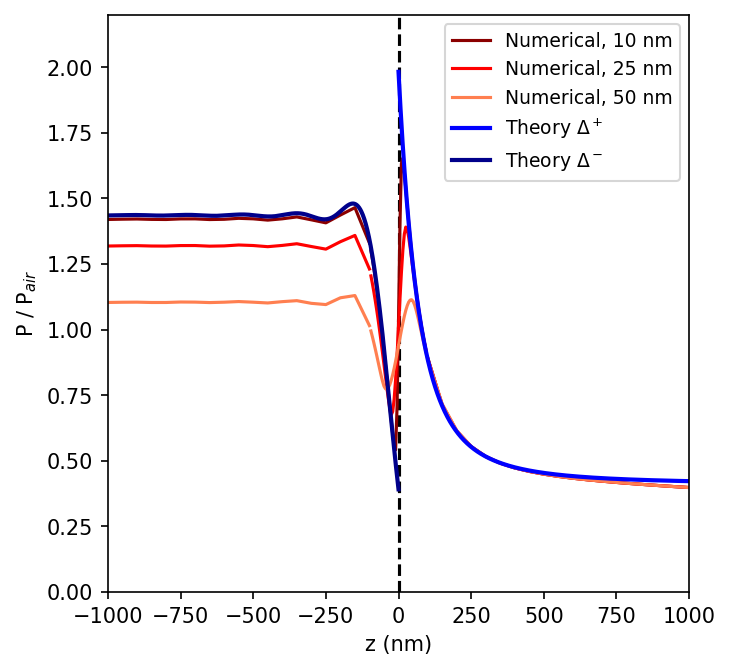

In [11]:
plt.figure(figsize=(5,5),dpi=150)
vals=np.arange(1,501,25)

plt.plot([0,0],[0,2.2],'--',color='black')


vals=np.arange(0,100,5)
above10, _ =GetPowerFromComsolFile("Data/Export_Power_Above_10_fine_sphere.txt",vals)
below10, _ =GetPowerFromComsolFile("Data/Export_Power_Below_10_fine_sphere.txt",vals)
plt.plot(vals,np.array(list(above10.values()))/normsphere["1_10"]*nglass,'-',color='DarkRed',label='Numerical, 10 nm')
plt.plot(-vals,np.array(list(below10.values()))/normsphere["1_10"]*nglass,'-',color='DarkRed')

above25, _ =GetPowerFromComsolFile("Data/Export_Power_Above_25_fine_sphere.txt",vals)
below25, _ =GetPowerFromComsolFile("Data/Export_Power_Below_25_fine_sphere.txt",vals)
plt.plot(vals,np.array(list(above25.values()))/normsphere["1_25"]*nglass,'-',color='red',label='Numerical, 25 nm')
plt.plot(-vals,np.array(list(below25.values()))/normsphere["1_25"]*nglass,'-',color='red')

dot25=below25[0]

above50, _ =GetPowerFromComsolFile("Data/Export_Power_Above_50_fine_sphere.txt",vals)
below50, _ =GetPowerFromComsolFile("Data/Export_Power_Below_50_fine_sphere.txt",vals)
plt.plot(vals,np.array(list(above50.values()))/normsphere["1_50"]*nglass,'-',color='coral',label='Numerical, 50 nm')
plt.plot(-vals,np.array(list(below50.values()))/normsphere["1_50"]*nglass,'-',color='coral')


vals=np.arange(100,1001,50)
above10, _ =GetPowerFromComsolFile("Data/Export_Power_Above_10_longer_sphere.txt",vals)
below10, _ =GetPowerFromComsolFile("Data/Export_Power_Below_10_longer_sphere.txt",vals)
plt.plot(vals,np.array(list(above10.values()))/normsphere["1_10"]*nglass,'-',color='DarkRed')
plt.plot(-vals,np.array(list(below10.values()))/normsphere["1_10"]*nglass,'-',color='DarkRed')

above25, _ =GetPowerFromComsolFile("Data/Export_Power_Above_25_longer_sphere.txt",vals)
below25, _ =GetPowerFromComsolFile("Data/Export_Power_Below_25_longer_sphere.txt",vals)
plt.plot(vals,np.array(list(above25.values()))/normsphere["1_25"]*nglass,'-',color='red')
plt.plot(-vals,np.array(list(below25.values()))/normsphere["1_25"]*nglass,'-',color='red')

above50, _ =GetPowerFromComsolFile("Data/Export_Power_Above_50_longer_sphere.txt",vals)
below50, _ =GetPowerFromComsolFile("Data/Export_Power_Below_50_longer_sphere.txt",vals)
plt.plot(vals,np.array(list(above50.values()))/normsphere["1_50"]*nglass,'-',color='coral')
plt.plot(-vals,np.array(list(below50.values()))/normsphere["1_50"]*nglass,'-',color='coral')

plt.plot(theory_deltas, totpower_theory_up,color='blue',label='Theory $\Delta^+$',linewidth=2)
plt.plot(-theory_deltas, totpower_theory_down,color='DarkBlue',label='Theory $\Delta^-$',linewidth=2)


#plt.plot([0],[below10[0]/normsphere["1_10"]],'o',color='black')
#plt.plot([0],[totpower_theory_down[0]],'v',color='black',markersize=10)
#plt.plot([0],[totpower_theory_up[0]],'^',color='black',markersize=10)
#plt.plot([0],[totpower_theory_down[0]*tryit],'s',color='black',markersize=8)
#plt.plot([0],[below50[0]/normsphere["1_50"]],'*tryito',solor='black')




plt.xlim(-1000,1000)

#plt.plot(refind[range(0,5)])
#plt.plot(refind[range(5,10)])
#plt.plot(np.arange(0,3001,25),totpower_theory_down)
plt.ylim(0,2.2)
plt.legend(loc='upper right',fontsize=9)
plt.ylabel(r"P / P$_{air}$")
plt.xlabel(r"z (nm)")

/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_12697/1114346989.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dat=pd.read_csv(fname,skiprows=8,delim_whitespace=True,names=cols)
/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_12697/1114346989.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dat=pd.read_csv(fname,skiprows=8,delim_whitespace=True,names=cols)
/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_12697/1114346989.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dat=pd.read_csv(fname,skiprows=8,delim_whitespace=True,names=cols)
/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_12697/1114346989.py:7: FutureWarning: The 'delim_whitespace' k

0.9753937998268297

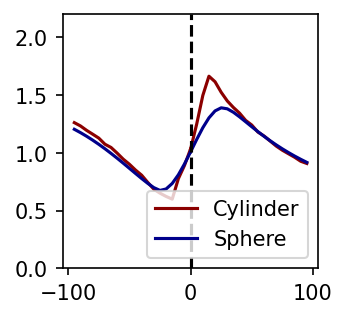

In [12]:


plt.figure(figsize=(2.2,2.2),dpi=150)
vals=np.arange(0,100,5)
above25, _ =GetPowerFromComsolFile("Data/Export_Power_Above_25_fine.txt",vals)
below25, _ =GetPowerFromComsolFile("Data/Export_Power_Below_25_fine.txt",vals)
plt.plot(vals,np.array(list(above25.values()))/normcyl["1_25"]*nglass,color='DarkRed',label='Cylinder')
plt.plot(-vals,np.array(list(below25.values()))/normcyl["1_25"]*nglass,color='DarkRed')
cyl=np.array(list(below25.values()))[0]/normcyl["1_25"]
totpower_theory_up[0]/(np.array(list(below25.values()))[0]/normcyl["1_25"])
vals=np.arange(0,100,5)
above25, _ =GetPowerFromComsolFile("Data/Export_Power_Above_25_fine_sphere.txt",vals)
below25, _ =GetPowerFromComsolFile("Data/Export_Power_Below_25_fine_sphere.txt",vals)
plt.plot(vals,np.array(list(above25.values()))/normsphere["1_25"]*nglass,color='DarkBlue',label='Sphere')
plt.plot(-vals,np.array(list(below25.values()))/normsphere["1_25"]*nglass,color='DarkBlue')
sph=np.array(list(below25.values()))[0]/normsphere["1_25"]
totpower_theory_up[0]/(np.array(list(below25.values()))[0]/normsphere["1_25"])
plt.plot([0,0],[0,2.2],'--',color='black')
plt.ylim(0,2.2)
plt.legend(loc='lower right')
sph/cyl
           

In [13]:
vals=[1,1.25,1.5,1.75,2]
normsph, dat=GetPowerFromComsolFile("Data/Export_Power_spheres_denominators.txt",vals)


/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_12697/1114346989.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dat=pd.read_csv(fname,skiprows=8,delim_whitespace=True,names=cols)


/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_12697/1114346989.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dat=pd.read_csv(fname,skiprows=8,delim_whitespace=True,names=cols)
/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_12697/1114346989.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dat=pd.read_csv(fname,skiprows=8,delim_whitespace=True,names=cols)
/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_12697/1114346989.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dat=pd.read_csv(fname,skiprows=8,delim_whitespace=True,names=cols)
/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_12697/1114346989.py:7: FutureWarning: The 'delim_whitespace' k

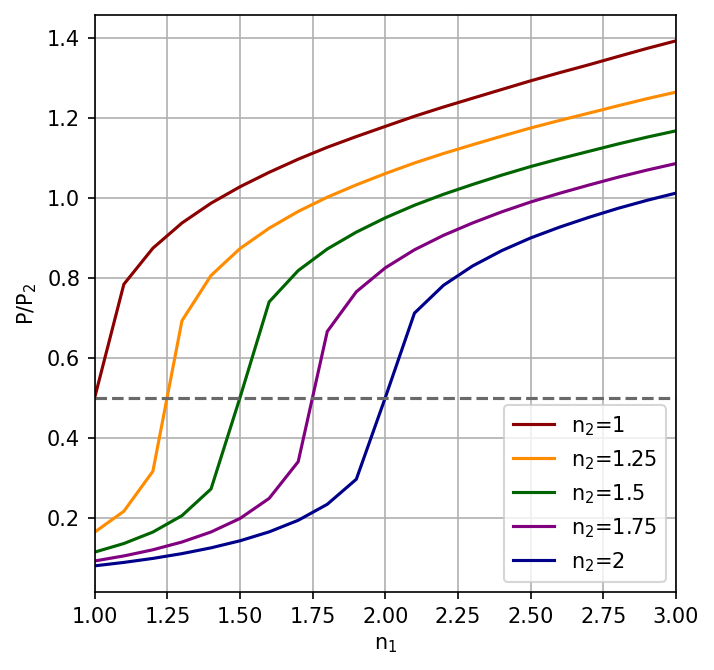

In [14]:
plt.figure(figsize=(5,5),dpi=150)
indices=np.arange(1,3.1,0.1)

cols={"1":"DarkRed",
    "1.25":"DarkOrange",
    "1.5":"DarkGreen",
    "1.75":"purple",
    "2":"DarkBlue"}


for n2 in ["1","1.25","1.5","1.75","2"]:    
    
    refind, dat =GetPowerFromComsolFile("Data/Export_Power_refindices_"+n2+".txt",indices)
    n1s=np.array(list(refind.keys()))
    Ps=np.array(list(refind.values()))*n1s
    plt.plot(n1s,Ps/(normsph[float(n2)]*float(n2)),'-',label='n$_2$='+n2,color=cols[n2])
    
ns=np.linspace(1,3,100)
totpower_theory_down_ns=[]

plt.plot([1,3],[0.5,0.5],"--",color='dimgrey')
plt.xlabel(r"n$_1$")
plt.ylabel(r"P/P$_{2}$")
plt.legend(loc='lower right')
vars=np.linspace(1,3,100)
plt.xlim(1,3)
plt.grid()


/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_12697/1114346989.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dat=pd.read_csv(fname,skiprows=8,delim_whitespace=True,names=cols)
/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_12697/1114346989.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dat=pd.read_csv(fname,skiprows=8,delim_whitespace=True,names=cols)
/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_12697/1114346989.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dat=pd.read_csv(fname,skiprows=8,delim_whitespace=True,names=cols)
/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_12697/1114346989.py:7: FutureWarning: The 'delim_whitespace' k

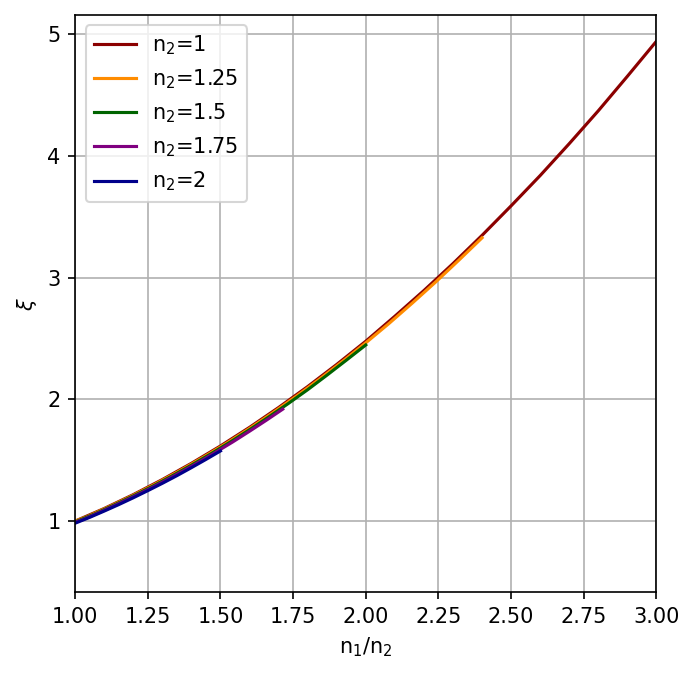

In [15]:
plt.figure(figsize=(5,5),dpi=150)
indices=np.arange(1,3.1,0.1)+1e-6
cols={"1":"DarkRed",
    "1.25":"DarkOrange",
    "1.5":"DarkGreen",
    "1.75":"purple",
    "2":"DarkBlue"}

for n2 in ["1","1.25","1.5","1.75","2"]:    

    refind, dat =GetPowerFromComsolFile("Data/Export_Power_refindices_"+n2+".txt",indices)
    totpower_theory_down_ns=[]
    for n1 in refind.keys():
        pow_dipabove_down=Power_dipoleside(float(n1)+1e-6, float(n2), k ,0,p_vec,phi,thetas)
        totpower_theory_down_ns.append(2.*np.pi*sum(np.abs(np.sin(thetas))*np.abs(pow_dipabove_down))*(np.pi/(2*len(thetas))))
    
    pow_dipabove_down_norm=Power_dipoleside(float(n2)+1e-6,float(n2) , k ,0,p_vec,phi,thetas)
    totpower_theory_down_norm=2.*np.pi*sum(np.abs(np.sin(thetas))*np.abs(pow_dipabove_down_norm))*(np.pi/(2*len(thetas)))
            
    n1s=np.array(list(refind.keys()))
    Ps=np.array(list(refind.values()))*n1s
    plt.plot(n1s/float(n2),(2.*Ps/(normsph[1]*float(n2))/(np.array(totpower_theory_down_ns)/totpower_theory_down_norm))**0.5,label='n$_2$='+n2,color=cols[n2])

ns=np.linspace(1,3,100)

plt.xlabel(r"n$_1$/n$_2$")
plt.ylabel(r"$\xi$")
plt.legend(loc='upper left')
plt.xlim(1,3)
plt.grid()


In [16]:
def CorrectWay1(th):
    return np.arctan(1.5**2*np.tan(th))
def CorrectWay2(th):
    return np.arctan(1.5**-2*np.tan(th))

Text(0, 0.5, 'Counts (arb)')

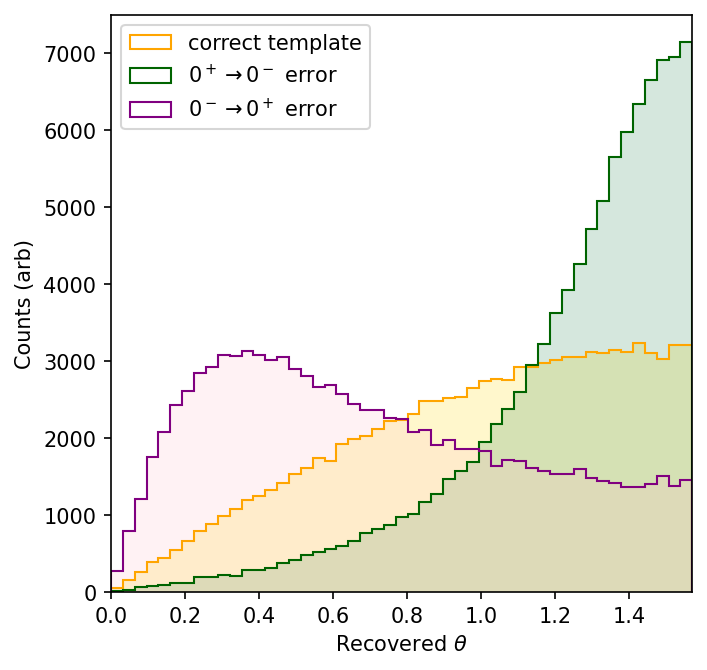

In [17]:
plt.figure(figsize=(5,5),dpi=150)

costhetas=np.random.random(100000)
plt.hist(np.arccos(costhetas),color='gold',alpha=0.2,bins=np.linspace(0,np.pi/2,50))
plt.hist(CorrectWay1(np.arccos(costhetas)),color='SeaGreen',alpha=0.2,bins=np.linspace(0,np.pi/2,50))
plt.hist(CorrectWay2(np.arccos(costhetas)),color='pink',alpha=0.2,bins=np.linspace(0,np.pi/2,50))

plt.hist(np.arccos(costhetas),color='orange',bins=np.linspace(0,np.pi/2,50),histtype='step',label='correct template')
plt.hist(CorrectWay1(np.arccos(costhetas)),color='DarkGreen',bins=np.linspace(0,np.pi/2,50),histtype='step',label=r'$0^+\rightarrow0^-$ error')
plt.hist(CorrectWay2(np.arccos(costhetas)),color='purple',bins=np.linspace(0,np.pi/2,50),histtype='step',label=r'$0^-\rightarrow0^+$ error')
plt.legend(loc='upper left')
plt.xlim(0,np.pi/2)
plt.xlabel(r"Recovered $\theta$")
plt.ylabel("Counts (arb)")

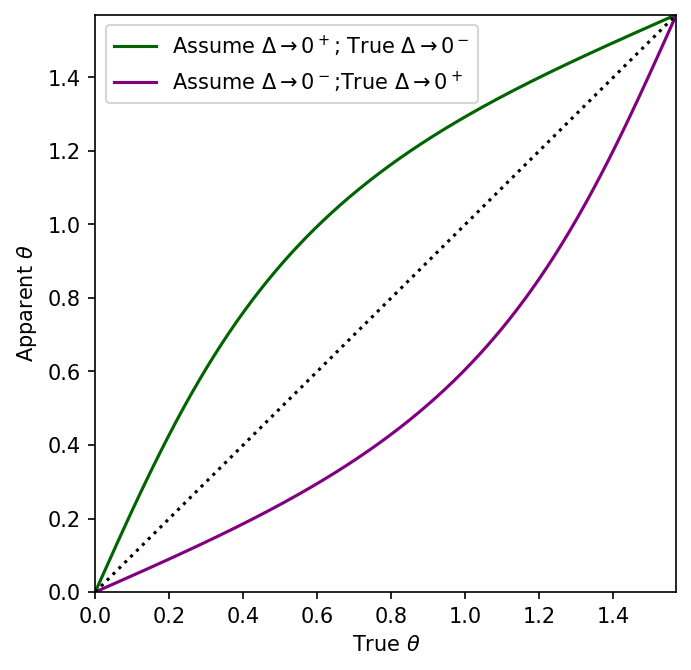

In [18]:
plt.figure(figsize=(5,5),dpi=150)
vars=np.linspace(0,np.pi/2,1000)
plt.plot(vars,np.arctan(1.5**2*np.tan(vars)),label=r'Assume $\Delta\rightarrow0^+$; True $\Delta\rightarrow0^-$',color='DarkGreen')
plt.plot(vars,np.arctan(1.5**-2*np.tan(vars)),label=r'Assume $\Delta\rightarrow0^-$;True $\Delta\rightarrow0^+$',color='purple')
plt.plot([0,np.pi/2],[0,np.pi/2],':',color='black')
plt.xlim(0,np.pi/2)
plt.ylim(0,np.pi/2)
plt.xlabel(r"True $\theta$")
plt.ylabel(r"Apparent $\theta$")
plt.legend(loc='upper left')